Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35798431943915787..0.9999999999999999].


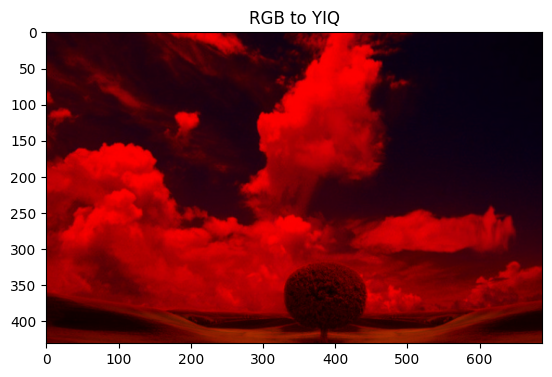

In [2]:
# Program to convert RGB image to YIQ

# Import OpenCV library
import cv2

# Import NumPy for matrix calculations
import numpy as np

# Import Matplotlib for displaying image
import matplotlib.pyplot as plt

# Syntax:
# cv2.imread(filename)

# Read image from file
# OpenCV reads image in BGR format by default
img = cv2.imread("image.jpg")

# Syntax:
# cv2.cvtColor(src, code)

# Convert BGR to RGB
# Why?
# OpenCV stores image as BGR
# Matplotlib expects RGB
# Therefore convert BGR → RGB

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Syntax:
# array.astype(datatype)

# Convert image data type to float32
# Why?
# Matrix calculations work more accurately with decimal values

rgb = rgb.astype(np.float32)

# Convert pixel values from 0-255 to 0-1
# Why?
# Mathematical color conversions usually use values between 0 and 1

rgb = rgb / 255.0

# Syntax:
# np.array([[...],[...],[...]])

# YIQ conversion matrix
#
# First row calculates Y (Brightness)
# Y = 0.299R + 0.587G + 0.114B
#
# Second row calculates I component
# I stores Orange ↔ Blue color information
#
# Third row calculates Q component
# Q stores Purple ↔ Green color information
#
# Used in old NTSC television systems

yiq_matrix = np.array([
    [0.299, 0.587, 0.114],
    [0.596, -0.275, -0.321],
    [0.212, -0.523, 0.311]
])

# Syntax:
# np.dot(array1, array2)

# .T means transpose of matrix
#
# Why transpose?
# Matrix multiplication requires matching rows and columns
#
# np.dot performs matrix multiplication
#
# Every RGB pixel is converted into YIQ values

yiq = np.dot(rgb, yiq_matrix.T)

# Syntax:
# plt.imshow(image)

# Display YIQ image

plt.imshow(yiq)

# Syntax:
# plt.title(title)

# Add title to output image

plt.title("RGB to YIQ")

# Syntax:
# plt.show()

# Display output window

plt.show()
# YIQ Conversion Matrix

# First Row -> Calculates Y (Brightness)

# Y = 0.299R + 0.587G + 0.114B

# 0.299 -> Contribution of Red
# 0.587 -> Contribution of Green
# 0.114 -> Contribution of Blue

# Green has highest weight because
# human eyes are most sensitive to green.

# Second Row -> Calculates I component

# I = 0.596R - 0.275G - 0.321B

# I stores Orange ↔ Blue color information

# Third Row -> Calculates Q component

# Q = 0.212R - 0.523G + 0.311B

# Q stores Purple ↔ Green color information

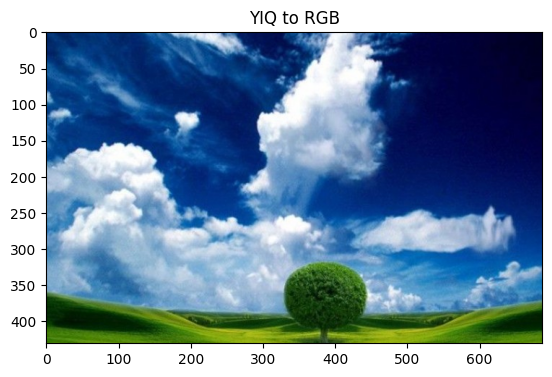

In [3]:
# Program to convert YIQ image to RGB

# Import OpenCV library
import cv2

# Import NumPy for matrix calculations
import numpy as np

# Import Matplotlib for displaying image
import matplotlib.pyplot as plt

# Syntax:
# cv2.imread(filename)

# Read image from file
# OpenCV reads image in BGR format by default

img = cv2.imread("image.jpg")

# Syntax:
# cv2.cvtColor(src, code)

# Convert BGR to RGB
# Why?
# OpenCV stores image as BGR
# Matplotlib expects RGB

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert pixel values from 0-255 to 0-1
# Why?
# Matrix calculations are more accurate with values between 0 and 1

rgb = rgb.astype(np.float32) / 255.0

# YIQ Conversion Matrix
#
# Y = Brightness
# I = Orange ↔ Blue information
# Q = Purple ↔ Green information

yiq_matrix = np.array([
    [0.299,  0.587,  0.114],
    [0.596, -0.275, -0.321],
    [0.212, -0.523,  0.311]
])

# Syntax:
# np.dot(array1, array2)

# Convert RGB to YIQ
# .T means transpose of matrix

yiq = np.dot(rgb, yiq_matrix.T)

# Syntax:
# np.linalg.inv(matrix)

# Find inverse of YIQ matrix
# Why?
# RGB → YIQ uses yiq_matrix
# YIQ → RGB needs the inverse matrix
# to reverse the conversion

inverse_matrix = np.linalg.inv(yiq_matrix)

# Convert YIQ back to RGB

rgb2 = np.dot(yiq, inverse_matrix.T)

# Syntax:
# np.clip(array, min, max)

# Keep pixel values between 0 and 1
# Prevents invalid RGB values

rgb2 = np.clip(rgb2, 0, 1)

# Syntax:
# plt.imshow(image)

# Display RGB image

plt.imshow(rgb2)

# Syntax:
# plt.title(title)

plt.title("YIQ to RGB")

# Syntax:
# plt.show()

plt.show()